# Visualización 7: Comparativa de Dispersión Tonal entre Archivos

**Finalidad de este notebook:**
El objetivo de esta sección es comparar estadísticamente el comportamiento tonal (Pitch) de múltiples piezas musicales simultáneamente. Para lograrlo, en lugar de graficar todas las notas, dividiremos cada obra en particiones de tiempo iguales y calcularemos la media tonal de cada segmento.

Esta técnica nos permitirá responder preguntas como:
* ¿Una pieza tiende a ser más aguda o grave en promedio que otra?
* ¿Qué tanta variación interna (dispersión) tiene una obra a lo largo de su ejecución?

Para la visualización, combinaremos dos herramientas poderosas: los **Diagramas de Caja (*Boxplots*)** y los **Gráficos de Dispersión (*Stripplots*)**.
Además y muy importante, poder visualizar la estacionariedad de los datos con la agrupación previamente mencionada.

---
### 1. Importación de dependencias

Cargamos las librerías principales:
* **`pandas`**: Para estructurar las medias calculadas en un DataFrame tabular.
* **`numpy`**: Utilizaremos `np.array_split` para dividir las notas en lotes y `np.mean` para los cálculos estadísticos.
* **`seaborn`**: Herramienta principal para generar visualizaciones estadísticas atractivas y complejas con pocas líneas de código.


In [1]:
import os
from glob import glob
import random
import mido
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Carga del conjunto de datos

Definimos la ruta del dataset y obtenemos todos los archivos `.midi` disponibles. De esta lista, seleccionaremos un subconjunto para comparar sus distribuciones tonales.


In [2]:
ruta_base = '../maestro-v3.0.0'
archivos = glob(os.path.join(ruta_base, '**/*.midi*'), recursive=True)

### 3. Lógica de Agrupación, Cálculo y Visualización Combinada

Implementamos la función `visualizar_panel_boxplots`. Su flujo de ejecución es el siguiente:

1. **Extracción y Filtrado**: Iteramos sobre un número definido de archivos (`n_archivos`), abriendo cada uno con `mido` y extrayendo una lista secuencial con el valor de las notas (Pitch) tocadas.
2. **Particionamiento (`np.array_split`)**: Dividimos la lista cronológica de notas en un número fijo de fragmentos (por defecto, `n_particiones=20`). Esto simula la división de la canción en "capítulos".
3. **Cálculo de Medias**: Se calcula el promedio tonal (`np.mean`) de cada fragmento.
4. **Construcción del DataFrame**: Agrupamos los datos generados en una estructura de Pandas que asocia el nombre del archivo con sus medias calculadas.
5. **Renderizado de Capas Múltiples**:
   * **Capa 1 (`sns.boxplot`)**: Dibuja el diagrama de caja para visualizar la mediana, el rango intercuartílico y la varianza general de la obra.
   * **Capa 2 (`sns.stripplot`)**: Dibuja puntos semitransparentes sobre las cajas. Cada punto representa la media real de un segmento específico de la canción, permitiendo ver la distribución exacta de los datos subyacentes.


In [ ]:
def visualizar_panel_boxplots(lista_archivos, n_archivos=10, n_particiones=20):
    todos_los_datos = []
    
    for i in range(min(n_archivos, len(lista_archivos))):
        ruta = lista_archivos[i]
        nombre = os.path.basename(ruta)[:15]
        
        mid = mido.MidiFile(ruta)
        notas = []
        for msg in mid:
            if msg.type == 'note_on' and msg.velocity > 0:
                notas.append(msg.note)
        
        if not notas: continue
        

        arrays_particionados = np.array_split(notas, n_particiones)
        
        medias_particion = [np.mean(p) for p in arrays_particionados if len(p) > 0]
        
        for m in medias_particion:
            todos_los_datos.append({'Archivo': f"ID_{i}: {nombre}", 'Media_Pitch': m})

    df_final = pd.DataFrame(todos_los_datos)
    
    plt.figure(figsize=(16, 7))
    sns.set_style("whitegrid")
    
    sns.boxplot(x='Archivo', y='Media_Pitch', data=df_final, palette='viridis', hue='Archivo', legend=False)
    
    sns.stripplot(x='Archivo', y='Media_Pitch', data=df_final, color='black', size=3, alpha=0.3)

    plt.title(f"Comparativa de Medias Particionadas (n={n_particiones}) por Archivo")
    plt.xticks(rotation=45, ha='right')
    plt.ylabel("Pitch Promedio")
    plt.xlabel("Archivos analizados")
    plt.tight_layout()
    plt.show()

### 4. Generación de la Comparativa

Invocamos la función pasando los primeros 10 archivos de nuestra colección para visualizar su comparativa estadística.

> **Guía de Interpretación:** 
> * **Eje Y (Pitch Promedio)**: Cajas situadas más arriba indican piezas interpretadas en un registro más agudo.
> * **Tamaño de la Caja**: Una caja muy "alta" o alargada indica que la pieza sufre cambios drásticos de registro (partes muy graves y partes muy agudas). Una caja achatada indica monotonía tonal.
> * **Puntos Negros (Stripplot)**: Cada punto es un "fragmento" de la canción. Si vemos puntos muy alejados de la caja, significa que la obra tuvo un pico inesperado (un solo muy agudo o muy grave) que se sale del comportamiento normal del resto de la pieza.


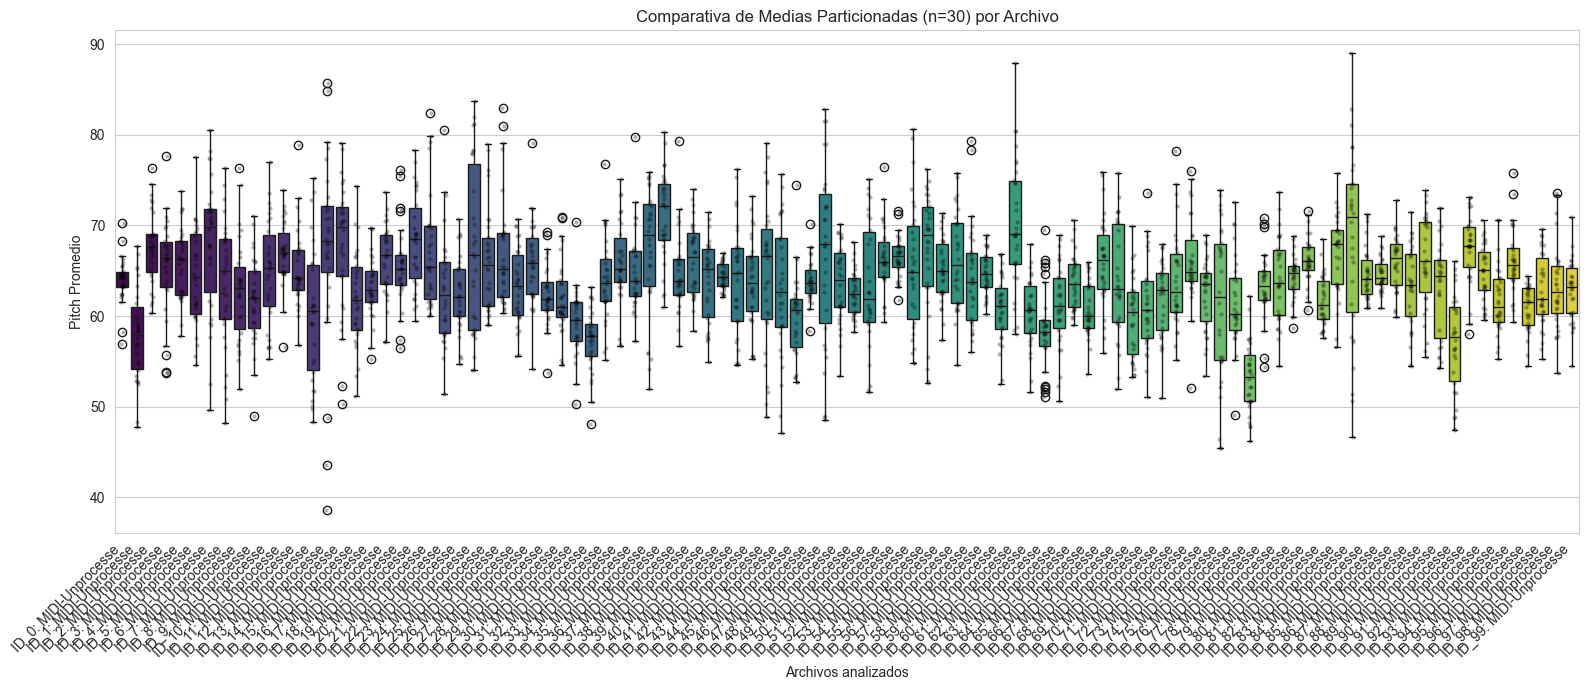

In [4]:
visualizar_panel_boxplots(archivos, n_archivos=100, n_particiones=30)

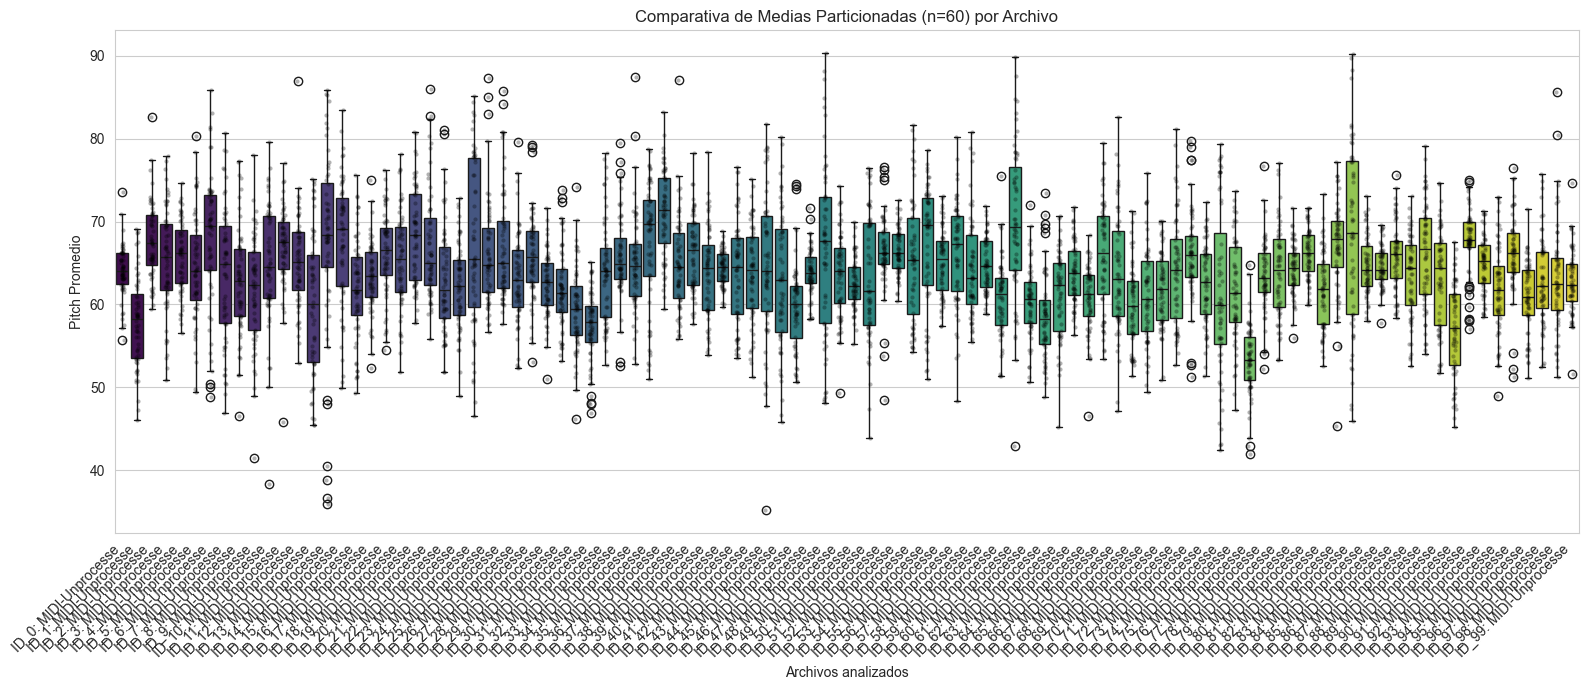

In [5]:
visualizar_panel_boxplots(archivos, n_archivos=100, n_particiones=60)

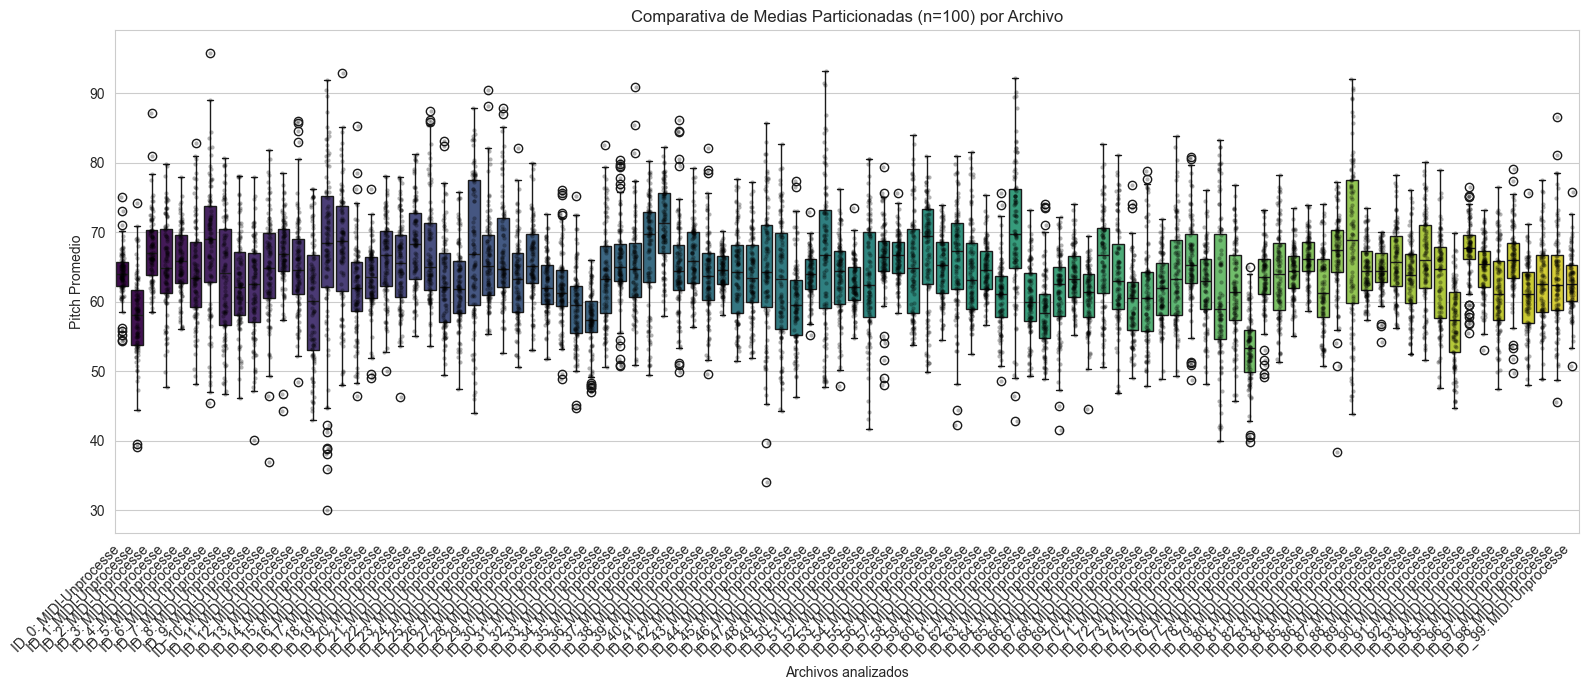

In [6]:
visualizar_panel_boxplots(archivos, n_archivos=100, n_particiones=100)